In [161]:
import json
import re
import os
import math
from collections import Counter
from collections import defaultdict
from augur.utils import json_to_tree
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.patches import ConnectionPatch
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import MaxNLocator
import pandas as pd
import numpy as np
from Bio.Seq import MutableSeq

## Figure 7: egg adaptation is stochastic, to some extent

In [9]:
# read in adaptive muts
adaptive_mut_file = f"../egg-mutation-analysis/egg-adaptive-muts/ha_HA1_adaptive-muts.json"

with open(adaptive_mut_file) as json_handle:
    egg_muts_info = json.load(json_handle)

adaptive_muts_by_virus = {}

for v in ['h3n2', 'h1n1pdm', 'vic', 'yam']:
    ha1_adaptive_muts= egg_muts_info['aas_at_adaptive_sites'][v]
    adaptive_muts_by_virus[v] = {int(k):v for k,v in ha1_adaptive_muts.items()}

In [11]:
def get_ha1_muts(virus, segment='ha'):
    """
    return the HA1 egg-passaging muts
    Limit just to adaptive muts
    """
    # get all muts that occurred during egg passaging for each strain
    curated_mut_file = f"../egg-mutation-analysis/egg-muts-by-strain/{virus}_{segment}_curated-egg-muts.json"
    
    with open(curated_mut_file) as json_handle:
        egg_mut_info = json.load(json_handle)
        
    # get the possible adaptive muts for this virus
    possible_adaptive_muts = adaptive_muts_by_virus[virus]
    
    egg_adaptive_muts = {}
    
    for strain, muts in egg_mut_info.items():
        ha1_egg_muts = muts['HA1']
        adaptive_ha1_muts = [x for x in ha1_egg_muts if x[-1] in possible_adaptive_muts.get(int(x[:-1]), [])]
        egg_adaptive_muts[strain] = adaptive_ha1_muts

    
    return egg_adaptive_muts

In [92]:
def apply_muts(root_seq, muts_list):
    """
    Apply a list of muts to the root sequence to get the sequence at an internal node
    """
    root_seq_w_muts = MutableSeq(root_seq)
    
    # doing this root to tip, so if there are multiple muts at same site, 
    # aa will be properly overwritten
    for m in muts_list:
        m_pos = int(m[1:-1])
        m_index = m_pos-1
        m_aa = m[-1]
        root_seq_w_muts[m_index] = m_aa
        
    seq_at_node = str(root_seq_w_muts)
    
    return seq_at_node

In [2]:
def get_seq_before_egg_passaging(virus):
    """
    For each egg-passaged strain, 
    get all HA1 mutations between the root and the egg-passaged strain (excluding the terminal branch)
    and apply this to root sequence to get the inferred unpassaged HA1 seq
    """
    
    tree_path= f'../nextstrain_builds/egg-enriched/auspice/{virus}_ha_egg.json'
    
    #read in the tree
    with open(tree_path, 'r') as f:
        tree_json = json.load(f)
        
    # ha1 aa seq at root
    ha1_root_seq = tree_json['root_sequence']['HA1']
        
    #put tree in Bio.phylo format
    tree = json_to_tree(tree_json)
    
    # store sequence of internal node before egg-seq here
    seqs_before_egg = {}
    
    for node in tree.find_clades(terminal=True):
        # find egg tips
        if node.node_attrs['passage_category']['value'] == 'egg':
            path_from_root = tree.get_path(node)[:-1]
            # get all HA1 muts on this path
            ha1_muts_on_path = []
            for n in path_from_root:
                ha1_muts_on_path += n.branch_attrs['mutations'].get('HA1', [])
            # now apply these muts to root seq to get HA1 aa sequence at internal node
            # before egg strain
            node_ha1_seq = apply_muts(ha1_root_seq, ha1_muts_on_path)
            seqs_before_egg[node.name] = node_ha1_seq
            
    # save mutation info to json           
    # Serializing json
    json_object_to_save = json.dumps(seqs_before_egg, indent=2)
    
    # save these sequences
    with open(f"../egg-mutation-analysis/before-egg-seqs/{virus}_HA1_seqs_before_egg.json", "w") as outfile:
        outfile.write(json_object_to_save)


In [3]:
def get_sets_of_replicates(virus):
    """
    Find sets of egg-passaged strains that have the same HA1 sequence prior to egg passaging
    """
    # check if we have already computed the sequence at internal node before egg passaging
    # and do this if not
    if not os.path.exists(f"../egg-mutation-analysis/before-egg-seqs/{virus}_HA1_seqs_before_egg.json"):
        get_seq_before_egg_passaging(virus)
        
    # read in sequences      
    with open(f"../egg-mutation-analysis/before-egg-seqs/{virus}_HA1_seqs_before_egg.json", 'r') as f:
        seqs_before_egg = json.load(f)
        
    # group egg strains by their sequences before passaging
    seq_to_strains = defaultdict(list)

    for k, v in seqs_before_egg.items():
        seq_to_strains[v].append(k)

    # get seqs with at least 3 strains
    replicate_sets = {value: keys for value, keys in seq_to_strains.items() if len(keys) > 2}
    
    # save sets of replicates  to json           
    # Serializing json
    json_object_to_save = json.dumps(replicate_sets, indent=2)
    
    # save these the sets of replicates
    with open(f"../egg-mutation-analysis/before-egg-seqs/{virus}_replicate_sets.json", "w") as outfile:
        outfile.write(json_object_to_save)

In [5]:
def get_dates(virus):
    """
    Return dictionary mapping node to date
    """
    tree_path= f'../nextstrain_builds/egg-enriched/auspice/{virus}_ha_egg.json'
    
    #read in the tree
    with open(tree_path, 'r') as f:
        tree_json = json.load(f)
        
    #put tree in Bio.phylo format
    tree = json_to_tree(tree_json)
    
    node_dates = {}
    
    for node in tree.find_clades():
        node_dates[node.name] = node.node_attrs['num_date']['value']
        
    return node_dates

In [6]:
def get_muts_in_replicates(virus):
    """
    Find which adaptive muts are in the replicate strains
    """
    # check if we have already found sets of "replicates"
    # and do this if not
    if not os.path.exists(f"../egg-mutation-analysis/before-egg-seqs/{virus}_replicate_sets.json"):
        get_sets_of_replicates(virus)
        
    # read in sets      
    with open(f"../egg-mutation-analysis/before-egg-seqs/{virus}_replicate_sets.json", 'r') as f:
        sets_of_replicates = json.load(f)
    
    # get the ha1 muts for each egg strain
    ha1_egg_muts = get_ha1_muts(virus)
    
    muts_in_replicates = {}
    
    for s, es in sets_of_replicates.items():
        muts_per_s = []
        for e in es:
#             if e in ha1_egg_muts.keys():
            e_muts = ha1_egg_muts[e]

            muts_per_s.append({e:e_muts})
            
        muts_in_replicates[s] = muts_per_s
        
    return muts_in_replicates

In [46]:
def get_replicates_data(virus, min_num_reps):
    """
    For each set of egg-passaged strains from the same unpassaged HA1 sequence,
    Get all egg-adaptive muts that occurred in that set
    And get the dates of all egg-passaged strains
    Limit sets to those that have at least min_num_reps egg strains
    """
    muts_in_replicates = get_muts_in_replicates(virus)
    
    node_dates = get_dates(virus)
        
    data_to_plot = []
    
    c = 0
    for par, reps in muts_in_replicates.items():
        # give "parent" an index instead of keeping track of the whole HA1 seq
        par_i = f'par_{c}'
        c+=1
        
        num_reps = len(reps)
        
        # require at least min_num_reps egg strains descend from parent node
        if num_reps>=min_num_reps:
            # keep track of all adaptive mut sites seen amongst egg strains in this set
            mut_sites_this_set = []
            # keep track of dates of all egg strains
            egg_dates = []
            for rep in reps:
                for n, ms in rep.items():
                    # date of this egg strain
                    n_date = node_dates[n]
                    egg_dates.append(n_date)
                    # adaptive sites
                    ms_pos = [int(x[:-1]) for x in ms]
                    mut_sites_this_set+=ms_pos
            
            mean_egg_date = sum(egg_dates)/len(egg_dates)
            num_mut_sites_this_set = len(set(mut_sites_this_set))
            # assign a categorical bin depending on number of sequences in set
            if num_reps <=5:
                size_bin = '<=5'
            elif 5<num_reps<=10:
                size_bin = '6-10'
            elif 10<num_reps<=20:
                size_bin = '11-20'
            elif 20<num_reps<=50:
                size_bin = '21-50'
            elif 50<num_reps:
                size_bin = '>50'
            
            data_to_plot.append({'set': par_i, 'mean_egg_date': mean_egg_date, 
                                 'num_egg_strains': num_reps, 'size_bin':size_bin,
                                 'num_mut_sites_this_set':num_mut_sites_this_set,
                                 'mut_sites_this_set': mut_sites_this_set})
                
    df = pd.DataFrame(data_to_plot)


    return df

In [127]:
def get_strain_year(virus):
    """
    Return the year for all egg-passaged strains    
    """
    
    tree_path= f'../nextstrain_builds/egg-enriched/auspice/{virus}_ha_egg.json'
    
    #read in the tree
    with open(tree_path, 'r') as f:
        tree_json = json.load(f)
        
    #put tree in Bio.phylo format
    tree = json_to_tree(tree_json)
    
    eggstrains_to_year = {}
    
    for node in tree.find_clades(terminal=True):
        passage = node.node_attrs['passage_category']['value']
        date = node.node_attrs['num_date']['value']
        year = math.trunc(date)
        if passage == 'egg':
            eggstrains_to_year[node.name] = year

            
    return eggstrains_to_year

In [125]:
def get_num_adaptive_muts_per_year(virus):
    """
    Find the number of different adaptive muts observed per year
    """
    # get year for each egg strain
    eggstrains_to_year = get_strain_year(virus)
    
    # get muts for each egg strain
    curated_mut_file = f"../egg-mutation-analysis/egg-muts-by-strain/{virus}_ha_curated-egg-muts.json"
    
    with open(curated_mut_file) as json_handle:
        egg_mut_info = json.load(json_handle)
    
    # get range of  years with egg strains
    max_year = max(eggstrains_to_year.values())
    min_year = min(eggstrains_to_year.values())
    
    # all adaptive muts observed each year
    adaptive_muts_by_year = {x:[] for x in range(min_year, max_year+1)}
    
    # also keep track of total number of egg strains in year
    total_egg_strains_by_year = {x:0 for x in range(min_year, max_year+1)}
    # and num of egg strains with an adaptive mut
    adapted_egg_strains_by_year = {x:0 for x in range(min_year, max_year+1)}
    

    for strain, muts in egg_mut_info.items():
        year = eggstrains_to_year[strain]
        # increase count of egg strains in this year
        total_egg_strains_by_year[year]+=1
        
        # find what muts this strain has
        has_mut = False
        for g, m_list in muts.items():
            if g=='HA1':
                for m in m_list:
                    m_pos = int(m[:-1])
                    # if this is an adaptive mut, add it to the yearly tracker
                    if m_pos in adaptive_muts_by_virus[virus].keys():
                        if m[-1] in adaptive_muts_by_virus[virus][m_pos]:
                            adaptive_muts_by_year[year].append(m)
                            # now we've seen an adaptive mut
                            has_mut = True
        # if this strain had an adaptive mut, add to the yearly count
        if has_mut == True:
            adapted_egg_strains_by_year[year]+=1
    
    
    
    return adaptive_muts_by_year, total_egg_strains_by_year, adapted_egg_strains_by_year

In [126]:
def counts_in_sliding_windows(virus, window_len):
    """
    Get the number of adaptive muts observed in each window
    Same for proportion of egg strains mut
    """
    
    adaptive_muts_by_year, total_egg_strains_by_year, adapted_egg_strains_by_year = get_num_adaptive_muts_per_year(virus)
    # get time range
    all_years = list(adaptive_muts_by_year.keys())
    windows = [all_years[i:i + window_len] for i in range(len(all_years) - window_len + 1)]
    
    # get proportion of egg strains mutated in window
    proportion_adapted_by_window = {}
    # the total number of strains in window store by window midpoint
    counts_per_window = {}
    for w in windows:
        w_total = 0
        adapted_total = 0
        for y in w:
            w_total+=total_egg_strains_by_year[y]
            adapted_total+=adapted_egg_strains_by_year[y]

        window_midpoint = (w[-1] + w[0])/2
        # if there are any egg strains in this window
        if w_total!=0:
            proportion_adapted_by_window[window_midpoint] = adapted_total/w_total
            counts_per_window[window_midpoint] = w_total
            
    
    # aggregate adaptive muts in window
    # store by window midpoint
    adaptve_muts_by_window = {}
    adaptive_sites_by_window = {}
    prevalent_adaptive_sites_by_window = {}
    for w in windows:
        adaptive_muts_in_w = []
        adaptive_sites_in_w = []
        for y in w:
            adaptive_muts_in_w+=adaptive_muts_by_year[y]
            adaptive_sites_in_w+=[x[:-1] for x in adaptive_muts_by_year[y]]
            
        window_midpoint = (w[-1] + w[0])/2
        adaptve_muts_by_window[window_midpoint] = adaptive_muts_in_w
        adaptive_sites_by_window[window_midpoint] = adaptive_sites_in_w
        # and only those that are mutated in the window at least twice times, or in at least 7.5% of strains
        prevalent_adaptive_sites_by_window[window_midpoint] = [x for x in adaptive_sites_in_w 
                                                               if adaptive_sites_in_w.count(x)>=2 
                                                               or adaptive_sites_in_w.count(x)/counts_per_window[window_midpoint] >=0.075]
        
    
    # now count how many of the adaptive muts were observed each window
    count_adaptive_muts_by_window = {y:len(set(ms)) for y, ms in adaptve_muts_by_window.items()}
    
    # also do this by residue, instead of exact mut
    count_adaptive_sites_by_window = {y:len(set([int(m[:-1]) for m in ms])) for y, ms in adaptve_muts_by_window.items()}
    
    # only count site if it is mutated at least 3 times in window
    count_prevalent_adaptive_sites_by_window = {y:len(set([int(m[:-1]) for m in ms])) for y, ms in prevalent_adaptive_sites_by_window.items()}
        
    
    return count_adaptive_muts_by_window, count_adaptive_sites_by_window, count_prevalent_adaptive_sites_by_window, proportion_adapted_by_window

In [148]:
cmap = {'yam': {'stop': '#fbba0a', 'start': '#feebb8'}, 
        'vic' :{'stop': '#FF4500', 'start':'#ffd4c4'},
        'h3n2':{'stop':'#6C3BAA', 'start':'#ddcfee'},
        'h1n1pdm': {'stop': '#45b6fe', 'start': '#ceecff'}}

In [197]:
def plot_muts_per_set(min_num_reps):
    """
    
    """
    #plot styling
    sns.set_style("white")
    plt.rcParams['figure.dpi']= 300
    plt.rcParams['font.family'] = 'Arial'
    
    fig, axes = plt.subplots(2,2, figsize=(10,6))
    
    prettify_names = {'h3n2': 'A/H3N2', 'h1n1pdm': 'A/H1N1pdm', 'vic': 'B/Vic', 'yam': 'B/Yam'}
    
    for i, virus in enumerate(['h3n2', 'h1n1pdm', 'vic', 'yam']):
        ax = axes.flatten()[i]
        
        df = get_replicates_data(virus, min_num_reps)
    
#         num_bins_seen = len(df['size_bin'].unique())
#         bins_seen = possible_size_bins[:num_bins_seen]
        possible_size_bins = ['<=5', '6-10', '11-20', '21-50', '>50']
    
        size_mapping = {
            '<=5': 20,
            '6-10': 40,
            '11-20': 60,
            '21-50': 80,
            '>50': 100
        }

        sns.scatterplot(data=df, x='mean_egg_date', y='num_mut_sites_this_set', 
                        size='size_bin', hue='size_bin', sizes=size_mapping,
                        size_order = reversed(possible_size_bins),
                        hue_order = possible_size_bins, legend=False,
                        palette= sns.color_palette(f"blend:{cmap[virus]['start']},{cmap[virus]['stop']}", n_colors=5),
                        ax=ax)
        
        (count_adaptive_muts_by_window, count_adaptive_sites_by_window, 
        count_prevalent_adaptive_sites_by_window, proportion_adapted_by_window) = counts_in_sliding_windows(virus, 3)
        
        overall_df = pd.DataFrame(list(count_adaptive_sites_by_window.items()), columns=['year', 'count'])
        
        sns.lineplot(x='year', y='count', data=overall_df, color=cmap[virus]['start'], 
                     legend=False, zorder=1, linestyle='--', ax=ax)
        
        # add one legend for all plots
        grey_palette = sns.color_palette(f"blend:#cecece,#767676", n_colors=5)
        if i == 1:
            legend_elements = []
            count=0
            for l,s in size_mapping.items():
                legend_elements.append(Line2D([0], [0], marker='o', color='w', 
                                              markerfacecolor=grey_palette[count], markersize=s*0.1+2, 
                                              lw=0, label=l))
                count+=1
                
            ax.legend(handles=legend_elements, bbox_to_anchor=(1,1), title='Num Egg Strains', bbox_transform=ax.transAxes)
            
        
        
        
        if i==0:
            ax.set_ylabel('Number of adaptive mutations in set', fontsize=12)
            ax.yaxis.set_label_coords(-0.1, -0.2)
        else:
            ax.set_ylabel('')
        if i in [2,3]:
            ax.set_xlabel('Mean date of egg strains in set', fontsize=12)
        else:
            ax.set_xlabel('')
            
        ax.yaxis.set_major_locator(MaxNLocator(integer=True))
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        
        ax.text(0.02, 0.95, f'{prettify_names[virus]}', fontsize=16, transform=ax.transAxes)
        
        


    plt.subplots_adjust(wspace=0.1, hspace=0.3)

    sns.despine()

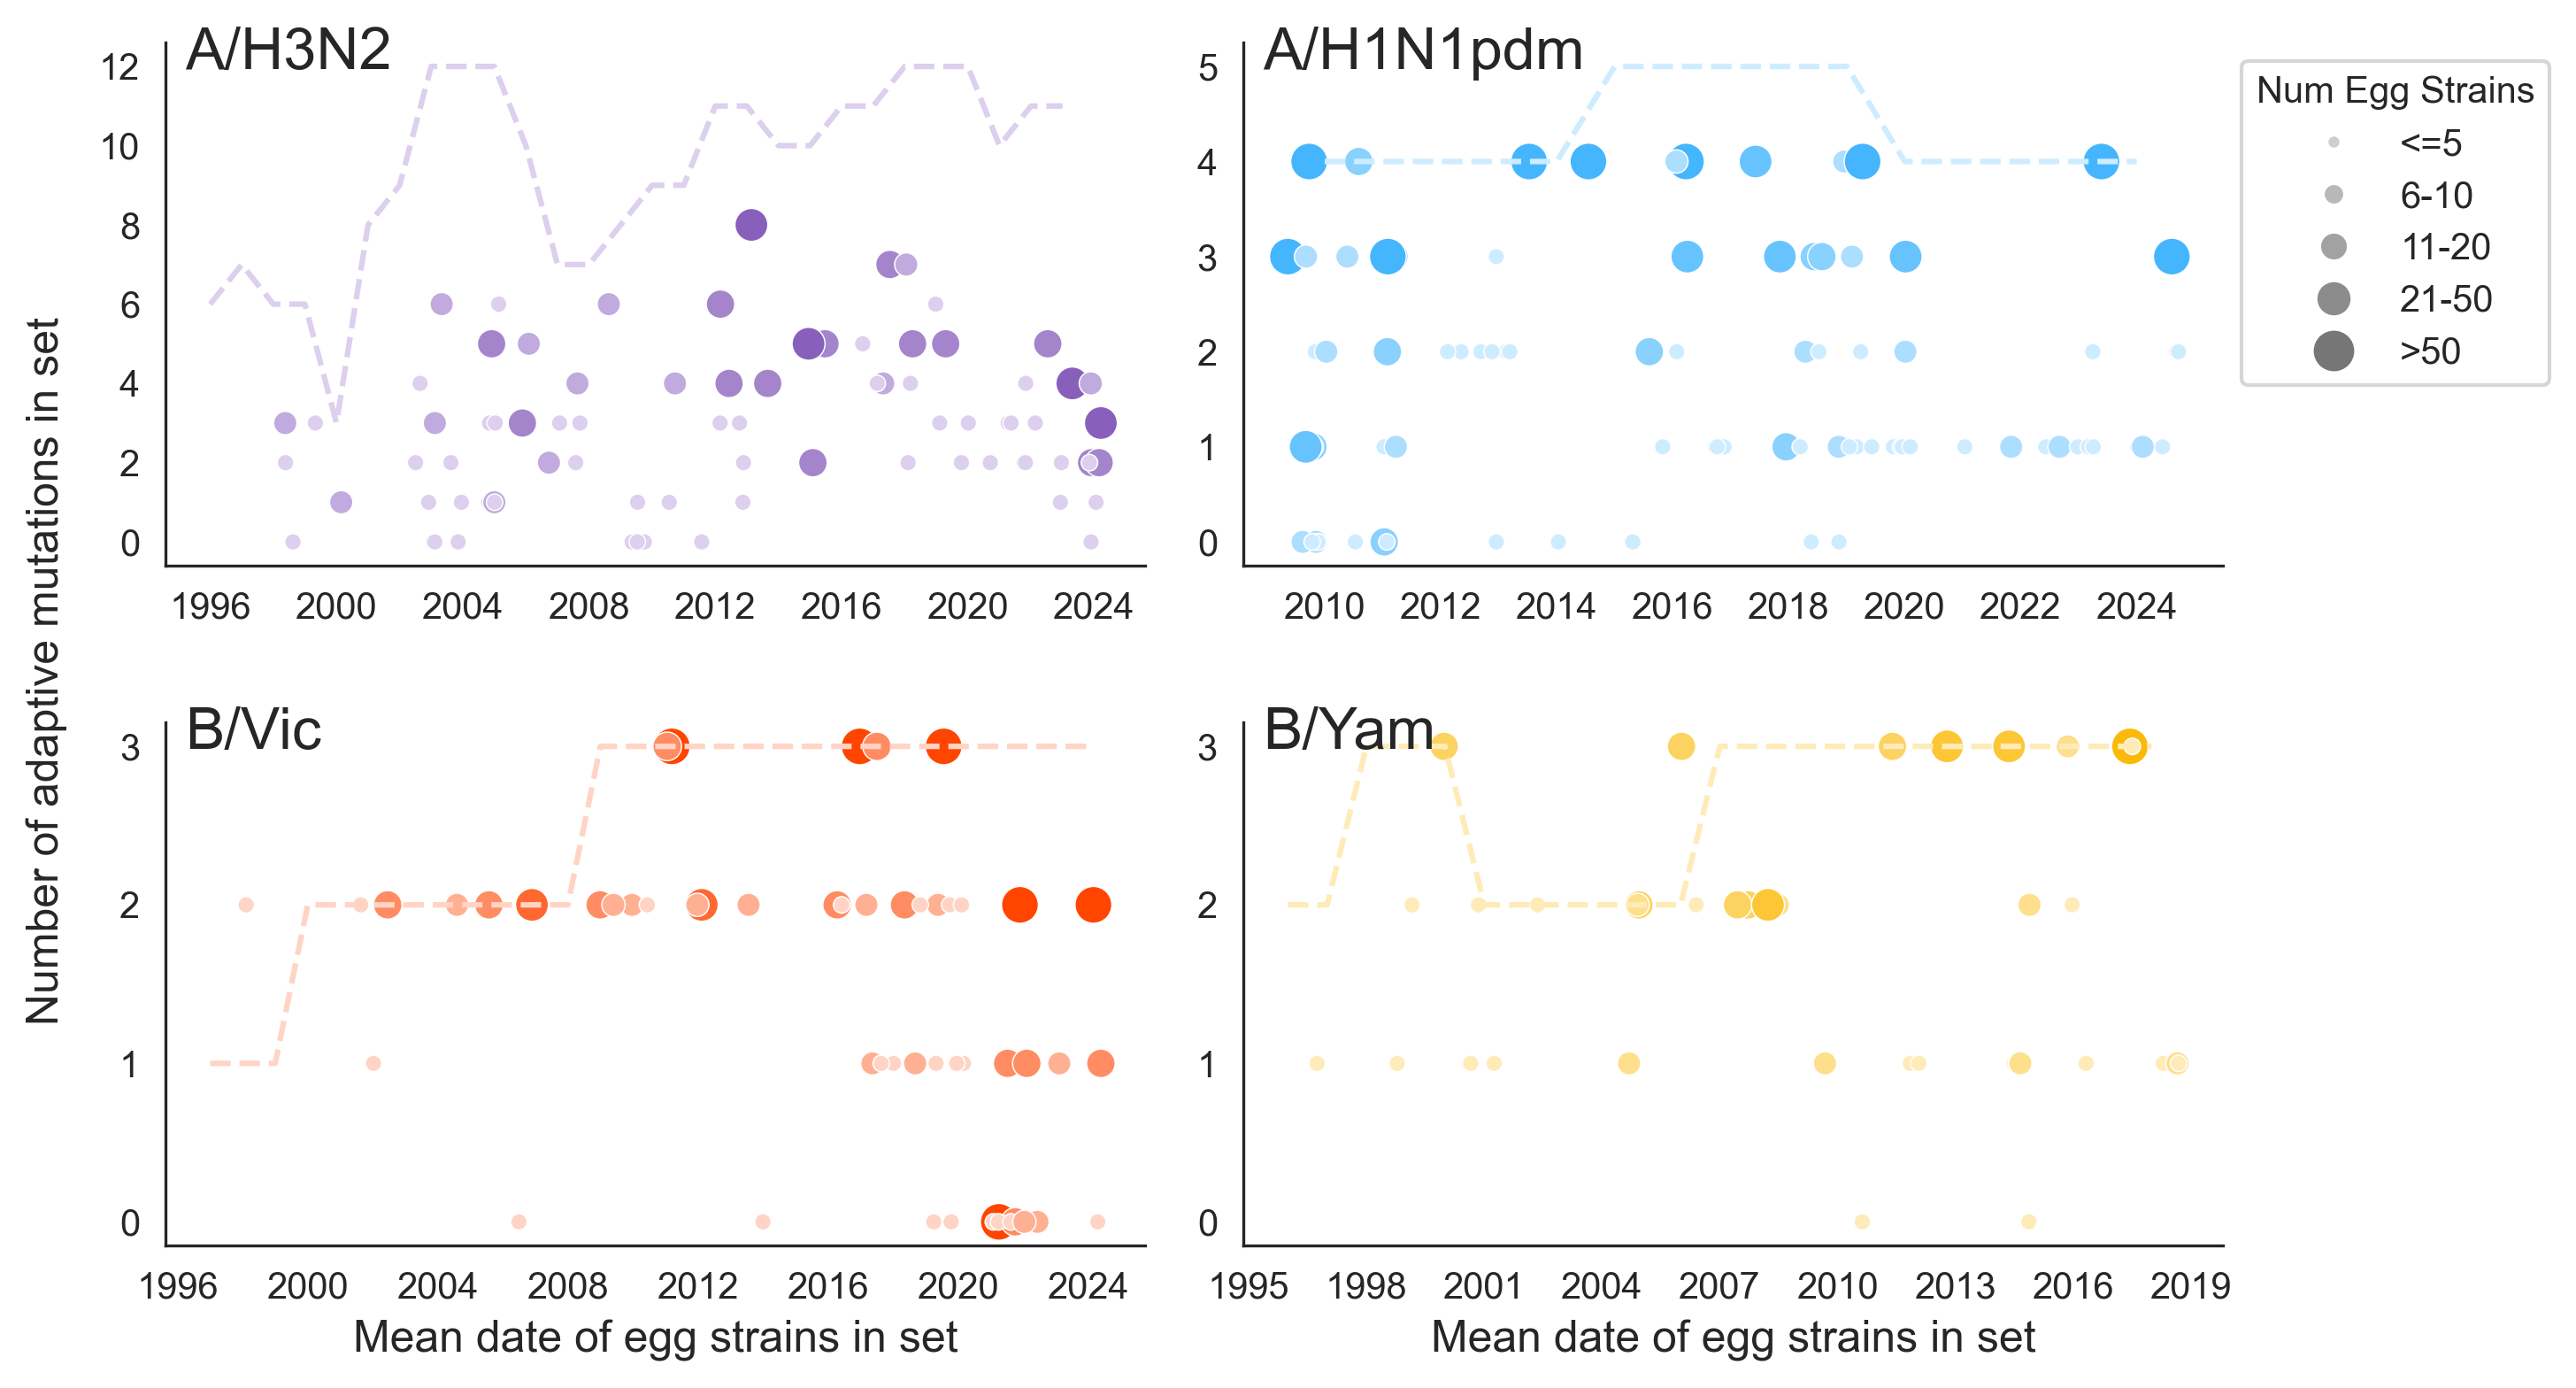

In [198]:
plot_muts_per_set(3)